<a href="https://colab.research.google.com/github/bruno-ritter/brazilain_stock_volatility_and_google_trends/blob/main/POC_TCC_Google_Trends_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas

In [ ]:
!pip install yfinance pandas pytrends tqdm arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 24.4 MB/s eta 0:00:00


In [ ]:
import time
import math
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import arch

from pytrends.request import TrendReq
from datetime import datetime, timedelta

from arch import arch_model
from arch.univariate import ConstantMean, GARCH, Normal
from arch.bootstrap import MCS



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Bases salvas

In [ ]:
df_acoes = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/acoes_elegiveis_v3.csv")
df_trends = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/google_trends_svi.csv", parse_dates=["semana"])
df_precos = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/precos_semanais_v3.csv", parse_dates=["semana"])
df_log = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/log_coleta_svi.csv")
df_adf = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/log_adf_svi.csv")
df_final = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/base_final_tcc.csv", parse_dates=["semana"])

df_previsoes = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/previsoes_consolidadas.csv", parse_dates=["semana"])
df_resumo_params = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/resumo_parametros.csv")

# Coleta dos dados

Para cada ação, coleta o preço no yahoo finance e o SVI com o ticker como termo de busca:
  1. TICKER     — ex: "PETR4"

In [ ]:
# ──────────────────────────────────────────────────────────────
# CONFIGURAÇÕES
# ──────────────────────────────────────────────────────────────
ANOS_HISTORICO    = 5
VOLUME_MIN_DIARIO = 1
SEMANAS           = 260
DATA_FIM          = datetime(2026, 3, 15).strftime("%Y-%m-%d")
DATA_INICIO       = (datetime(2026, 3, 15) - timedelta(weeks=SEMANAS)).strftime("%Y-%m-%d")
PAUSA_TRENDS      = 12     # segundos entre requisições
CAMINHO  = "/content/drive/MyDrive/TCC - Youtube e mercado financeiro/"

## Dados financeiros

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 1 — PREÇOS
# ──────────────────────────────────────────────────────────────

# Todos os ticker
tickers = pd.read_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/acoes-listadas-b3.csv")
TERMOS = list(tickers.Ticker)
tickers_yf = [t + ".SA" for t in TERMOS]

dados_raw = yf.download(
    tickers_yf, start=DATA_INICIO, end=DATA_FIM,
    auto_adjust=True, progress=True,
)

registros_acoes = []
for ticker_yf in tickers_yf:

    try:
        close  = dados_raw["Close"][ticker_yf].dropna()
        volume = dados_raw["Volume"][ticker_yf].dropna()

        if len(close) < ANOS_HISTORICO * 252 * 0.85:
            print(f"  [SKIP] {ticker_yf} — histórico insuficiente ({len(close)} dias)")
            continue

        vol_fin = (volume * close.mean()).mean()
        if vol_fin < VOLUME_MIN_DIARIO:
            print(f"  [SKIP] {ticker_yf} — liquidez insuficiente")
            continue

        registros_acoes.append({
            "ticker_yf": ticker_yf,
            "dias": len(close),
            "vol_fin_medio": round(vol_fin, 2),
        })
        print(f"  [OK] {ticker_yf} | Vol R${vol_fin:>14,.0f}")

    except Exception as e:
        print(f"  [ERRO] {ticker_yf}: {e}")

df_acoes = pd.DataFrame(registros_acoes)
df_acoes.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/acoes_elegiveis_v3.csv", index=False)
print(f"\n✅ {len(df_acoes)} ações elegíveis → acoes_elegiveis_v3.csv")

[*********************100%***********************]  387 of 387 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['BIOM11.SA', 'PINE11.SA', 'AZEV11.SA']: YFTzMissingError('possibly delisted; no timezone found')


  [OK] PETR4.SA | Vol R$ 1,210,975,123
  [OK] B3SA3.SA | Vol R$   499,094,883
  [OK] HAPV3.SA | Vol R$   409,380,888
  [OK] BEEF3.SA | Vol R$    81,652,351
  [OK] GMAT3.SA | Vol R$    34,957,446
  [OK] ENEV3.SA | Vol R$   122,175,356
  [OK] CSAN3.SA | Vol R$   201,455,924
  [OK] RAIZ4.SA | Vol R$    61,929,945
  [OK] COGN3.SA | Vol R$    87,962,749
  [OK] MBRF3.SA | Vol R$   114,409,379
  [OK] BBDC4.SA | Vol R$   560,890,492
  [OK] VAMO3.SA | Vol R$    63,007,929
  [OK] ITUB4.SA | Vol R$   771,721,048
  [OK] ABEV3.SA | Vol R$   314,727,503
  [OK] CPLE3.SA | Vol R$    34,169,765
  [OK] BBAS3.SA | Vol R$   490,705,722
  [OK] ITSA4.SA | Vol R$   207,866,784
  [OK] CSNA3.SA | Vol R$   137,580,532
  [OK] VALE3.SA | Vol R$ 1,486,093,157
  [OK] PRIO3.SA | Vol R$   466,796,500
  [OK] MGLU3.SA | Vol R$   723,354,399
  [OK] PETR3.SA | Vol R$   343,194,966
  [OK] CMIG4.SA | Vol R$    97,536,102
  [OK] ONCO3.SA | Vol R$    23,598,592
  [OK] CVCB3.SA | Vol R$   108,319,470
  [SKIP] NATU3.SA — histó

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 2 — VOLATILIDADE REALIZADA
# ──────────────────────────────────────────────────────────────

series_semanais = []
for _, row in df_acoes.iterrows():
    try:
        close  = dados_raw["Close"][row["ticker_yf"]].dropna()
        volume = dados_raw["Volume"][row["ticker_yf"]].dropna()

        df_d = pd.DataFrame({"close": close, "volume": volume})
        df_d.index = pd.to_datetime(df_d.index)

        df_d["log_ret"] = np.log(df_d["close"] / df_d["close"].shift(1))

        # Agrega semanalmente (semana fecha na sexta)
        wk = df_d.resample("W-FRI").agg(
            preco_abertura   = ("close",   "first"),
            preco_fechamento = ("close",   "last"),
            volume_total     = ("volume",  "sum"),
            n_preços         = ("log_ret", "count"), # nº de pregões na semana
            rv               = ("log_ret", lambda x: (x**2).sum()),  # RV = Σ r²
            ret_semanal      = ("log_ret", "sum"),
        ).dropna(subset=["rv"])

        wk["ticker_yf"] = row["ticker_yf"]
        wk["ticker_b3"] = row["ticker_yf"].replace(".SA", "")
        series_semanais.append(wk.reset_index().rename(columns={"Date": "semana"}))

    except Exception as e:
        print(f"  [ERRO preços {row['ticker_yf']}]: {e}")

df_precos = pd.concat(series_semanais, ignore_index=True)

# Retirar ações que não possuem o número de semanas correto
ticker_counts = df_precos.groupby("ticker_b3")["semana"].count()
tickers_corretos = ticker_counts[ticker_counts == SEMANAS].index
df_precos = df_precos[df_precos["ticker_b3"].isin(tickers_corretos)]


df_precos.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/precos_semanais_v3.csv", index=False)
print(f"✅ {len(df_precos)} linhas → precos_semanais_v3.csv")

✅ 86580 linhas → precos_semanais_v3.csv


## GOOGLE TRENDS: SVI POR TICKER

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 3 — GOOGLE TRENDS: SVI POR TICKER
# ──────────────────────────────────────────────────────────────

pytrends = TrendReq(hl="pt-BR", tz=-180)

def coletar_svi(ticker):
    """Retorna DataFrame semanal do SVI para um ticker ou None."""
    try:
        pytrends.build_payload(
            kw_list=[ticker],
            timeframe=f"{DATA_INICIO} {DATA_FIM}",
            geo="BR",
            gprop="",
        )
        df = pytrends.interest_over_time()
        if df.empty:
            return None
        df = df.drop(columns=["isPartial"], errors="ignore")
        df.columns = ["svi"]
        df.index.name = "semana"
        return df.reset_index()
    except Exception as e:
        print(f"    [ERRO '{ticker}']: {e}")
        return None


todos_trends = []
log_coleta   = []
tickers_validos = list(df_precos["ticker_b3"].unique())

for ticker in tickers_validos:

    print(f"\n  {ticker}")
    df_t = coletar_svi(ticker)
    time.sleep(PAUSA_TRENDS)

    if df_t is None:
        print("VAZIO")
        log_coleta.append({
            "ticker": ticker, "status": "vazio",
            "semanas": 0, "svi_media": None, "svi_std": None,
        })
        continue

    svi_media = round(df_t["svi"].mean(), 2)
    svi_std   = round(df_t["svi"].std(), 2)
    svi_zeros = (df_t["svi"] == 0).mean()
    print(f"OK | {len(df_t)} sem | média={svi_media:.1f} "
          f"std={svi_std:.1f} zeros={svi_zeros:.0%}")

    for _, tr in df_t.iterrows():
        todos_trends.append({
            "semana": tr["semana"],
            "ticker_b3": ticker,
            "svi":    tr["svi"],
        })

    log_coleta.append({
        "ticker":       ticker,
        "status":       "ok",
        "semanas":      len(df_t),
        "svi_media":    svi_media,
        "svi_std":      svi_std,
        "svi_zeros_pct": round(svi_zeros * 100, 1),
    })


df_trends = pd.DataFrame(todos_trends)
df_log    = pd.DataFrame(log_coleta)

# Calcular % de zeros por ticker no df_trends
zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
tickers_sem_sinal = zeros_pct[zeros_pct == 1.0].index
df_trends = df_trends[~df_trends["ticker_b3"].isin(tickers_sem_sinal)]

df_trends.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/google_trends_svi.csv", index=False)
df_log.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/log_coleta_svi.csv", index=False)

print(f"\n✅ {len(df_trends)} linhas → google_trends_svi.csv")
print(f"✅ Log de coleta    → log_coleta_svi.csv")


  PETR4
OK | 261 sem | média=28.9 std=9.5 zeros=0%

  B3SA3
OK | 261 sem | média=19.6 std=10.7 zeros=0%

  HAPV3
OK | 261 sem | média=10.8 std=9.2 zeros=0%

  BEEF3
OK | 261 sem | média=25.9 std=12.2 zeros=0%

  GMAT3
OK | 261 sem | média=26.5 std=15.3 zeros=0%

  ENEV3
OK | 261 sem | média=14.4 std=11.4 zeros=3%

  CSAN3
OK | 261 sem | média=18.6 std=9.4 zeros=0%

  COGN3
OK | 261 sem | média=34.6 std=15.8 zeros=0%

  MBRF3
OK | 261 sem | média=4.4 std=14.6 zeros=89%

  BBDC4
OK | 261 sem | média=24.4 std=9.3 zeros=0%

  VAMO3
OK | 261 sem | média=30.2 std=20.2 zeros=0%

  ITUB4
OK | 261 sem | média=40.1 std=11.0 zeros=0%

  ABEV3
OK | 261 sem | média=12.0 std=7.2 zeros=0%

  CPLE3
OK | 261 sem | média=40.2 std=19.5 zeros=0%

  BBAS3
OK | 261 sem | média=20.6 std=13.5 zeros=0%

  ITSA4
OK | 261 sem | média=41.8 std=13.2 zeros=0%

  CSNA3
OK | 261 sem | média=47.3 std=13.4 zeros=0%

  VALE3
OK | 261 sem | média=41.2 std=10.8 zeros=0%

  PRIO3
OK | 261 sem | média=36.2 std=10.0 zeros=0

## ESTACIONARIEDADE DO SVI (ADF POR TICKER)

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 4 — ESTACIONARIEDADE DO SVI (ADF POR TICKER)
# ──────────────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

NIVEL_SIGNIFICANCIA = 0.05

def teste_adf(serie, nome=""):
    """
    Roda o ADF e retorna dict com estatística, p-valor e conclusão.
    Usa seleção automática de lags (método 'AIC').
    """
    serie = serie.dropna()
    if len(serie) < 10:
        return {"stat": None, "pvalor": None, "estacionaria": None, "obs": "série curta"}

    stat, pvalor, _, _, valores_criticos, _ = adfuller(serie, autolag="AIC")
    estacionaria = pvalor < NIVEL_SIGNIFICANCIA

    # print(f"      {'[OK]' if estacionaria else '[RAIZ UNITÁRIA]'} {nome}: "
          # f"stat={stat:.3f}  p={pvalor:.4f}  {'estacionária' if estacionaria else 'não estacionária'}")

    return {
        "stat":         round(stat, 4),
        "pvalor":       round(pvalor, 4),
        "cv_1pct":      round(valores_criticos["1%"], 3),
        "cv_5pct":      round(valores_criticos["5%"], 3),
        "cv_10pct":     round(valores_criticos["10%"], 3),
        "estacionaria": estacionaria,
        "obs":          "",
    }


resultados_adf = []

for ticker, grupo in df_trends.groupby("ticker_b3"):

    # print(f"\n  {ticker}")
    svi = grupo.sort_values("semana")["svi"].reset_index(drop=True)

    # ── ADF no nível ──────────────────────────────────────────
    adf_nivel = teste_adf(svi, "SVI nível")

    # ── Primeira diferença e ADF ──────────────────────────────
    svi_diff  = svi.diff()
    adf_diff  = teste_adf(svi_diff, "SVI Δ(1)")

    resultados_adf.append({
        "ticker_b3":                   ticker,
        # nível
        "svi_adf_stat":             adf_nivel["stat"],
        "svi_adf_pvalor":           adf_nivel["pvalor"],
        "svi_estacionario":         adf_nivel["estacionaria"],
        # primeira diferença
        "svi_diff_adf_stat":        adf_diff["stat"],
        "svi_diff_adf_pvalor":      adf_diff["pvalor"],
        "svi_diff_estacionario":    adf_diff["estacionaria"],
    })

    # ── Adiciona coluna svi_diff ao df_trends ─────────────────
    df_trends.loc[df_trends["ticker_b3"] == ticker, "svi_diff"] = svi_diff.values


# ── Bases finais ──────────────────────────────────────────────
df_adf = pd.DataFrame(resultados_adf)

df_adf.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/log_adf_svi.csv", index=False)
df_trends.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/google_trends_svi.csv", index=False)

# ── Resumo ────────────────────────────────────────────────────
n_nivel_ok = df_adf["svi_estacionario"].sum()
n_diff_ok  = df_adf["svi_diff_estacionario"].sum()
n          = len(df_adf)

print(f"\n{'─'*55}")
print(f"  SVI nível estacionário:      {n_nivel_ok}/{n} tickers")
print(f"  SVI Δ(1)  estacionário:      {n_diff_ok}/{n} tickers")
print(f"\n✅ google_trends_svi.csv  → svi + svi_diff por semana")
print(f"✅ log_adf_svi.csv        → resultado ADF por ticker")


───────────────────────────────────────────────────────
  SVI nível estacionário:      230/324 tickers
  SVI Δ(1)  estacionário:      323/324 tickers

✅ google_trends_svi.csv  → svi + svi_diff por semana
✅ log_adf_svi.csv        → resultado ADF por ticker


## Base de dados final

In [ ]:
# ──────────────────────────────────────────────────────────────
# ETAPA 5 — MERGE: PREÇOS + TRENDS
# Uma linha por (semana, ticker)
# ──────────────────────────────────────────────────────────────

df_trends["semana"] = pd.to_datetime(df_trends["semana"])
df_precos["semana"] = pd.to_datetime(df_precos["semana"])

# Alinha domingo (Trends) → sexta (preços)
df_trends_temp = df_trends.copy()
df_trends_temp["semana"] = df_trends_temp["semana"] + pd.offsets.Week(weekday=4)

df_final = pd.merge(
    df_precos,
    df_trends_temp[["semana","ticker_b3","svi","svi_diff"]],
    on=["semana","ticker_b3"],
    how="inner",
).sort_values(["ticker_b3","semana"]).reset_index(drop=True)

# Selecionar apenas o ticker com SVI Diff estacionário
df_final = df_final[df_final["ticker_b3"].isin(df_adf[df_adf['svi_diff_estacionario'] == True]["ticker_b3"])]

# Retirar os valores NaN da primeira diferença do svi
df_final = df_final[df_final["svi_diff"].notna()]

# Retirar ativos com número de semanas errada
ticker_counts = df_final.groupby("ticker_b3")["semana"].count()
tickers_ok = ticker_counts[ticker_counts == (SEMANAS - 1)].index
df_final = df_final[df_final["ticker_b3"].isin(tickers_ok)]

df_final.to_csv("/content/drive/MyDrive/TCC - Youtube e mercado financeiro/base_final_tcc.csv", index=False)

print(f"✅ BASE FINAL → base_final_tcc.csv")

✅ BASE FINAL → base_final_tcc_v3.csv


# Especificação dos Modelos Competidores

## MODELO 0: PASSEIO ALEATÓRIO (Random Walk)
σ̂²_t = RV_{t-1}

In [ ]:
def passeio_aleatorio(grupo):
    df_t = (
        grupo.sort_values("semana")
        .reset_index(drop=True)
        [["semana", "rv"]]
        .copy()
    )
    df_t["rv_pred_m0"] = df_t["rv"].shift(1)
    return df_t.dropna(subset=["rv_pred_m0"])

## MODELO 1: GARCH(1,1) PADRÃO
σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}

Janela móvel de tamanho fixo: 52 * 3 semanas

In [ ]:
def garch_padrao(grupo, col_end="ret_semanal", janela=52 * 3):
    df_t = (
        grupo.sort_values("semana")
        .reset_index(drop=True)
        [["semana", "rv", col_end]]
        .copy()
    )
    n, previsoes = len(df_t), []

    for t in range(janela, n):
        treino = df_t[col_end].iloc[t - janela : t].values.astype(float) * 100
        try:
            fit = arch_model(treino, mean="Constant", vol="GARCH",
                             p=1, q=1, dist="normal").fit(disp="off", show_warning=False)
            var_pred = fit.forecast(horizon=1, reindex=False).variance.values[-1, 0] / 10_000
            previsoes.append({
                "semana":     df_t["semana"].iloc[t],
                "rv":          df_t["rv"].iloc[t],
                col_end:         df_t[col_end].iloc[t],
                "rv_pred_m1": var_pred,
                "omega":      fit.params.get("omega",    np.nan),
                "alpha":      fit.params.get("alpha[1]", np.nan),
                "beta":       fit.params.get("beta[1]",  np.nan),
            })
        except Exception as e:
            print(f"  [ERRO GARCH t={t}]: {e}")
            previsoes.append({"semana": df_t["semana"].iloc[t], "rv": df_t["rv"].iloc[t], col_end: df_t[col_end].iloc[t],
                              "rv_pred_m1": np.nan, "omega": np.nan, "alpha": np.nan, "beta": np.nan})

    return pd.DataFrame(previsoes)

## MODELO 2: GARCH-X(1,1)
$(σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1} + γ·ΔSVI_{t-1})$

Janela móvel de tamanho fixo: 52 * 3 semanas

---
O que muda em relação ao Modelo 1:

A única diferença estrutural é o exógeno $\gamma \cdot \Delta SVI_{t-1}$, que aparece em dois momentos distintos:

**Na estimação** — `x=svi_treino` passa os 156 valores de $\Delta SVI$ da janela para a biblioteca `arch` estimar o parâmetro $\gamma$ junto com $(\omega, \alpha, \beta)$.

**Na previsão** — `x=svi_previsao` passa apenas o valor $\Delta SVI_{t-1}$, que é o único ponto do exógeno disponível no momento em que a previsão é feita. Isso garante que não há *look-ahead bias* — na semana $t$ você só conhece o SVI até a semana $t-1$.

In [ ]:
def garch_exog(grupo, col_end="ret_semanal", col_exog="svi_diff", janela=52 * 3):
    df_t = (
        grupo.sort_values("semana")
        .reset_index(drop=True)
        [["semana", "rv", col_end, col_exog]]
        .dropna(subset=[col_exog])
        .reset_index(drop=True)
        .copy()
    )
    n, previsoes = len(df_t), []

    if n <= janela:
        print(f"  [AVISO] Obs. insuficientes ({n}), retornando vazio.")
        return pd.DataFrame()

    for t in range(janela, n):
        treino        = df_t[col_end].iloc[t - janela : t].values.astype(float)  * 100
        exog_treino   = df_t[col_exog].iloc[t - janela : t].values.astype(float).reshape(-1, 1)
        exog_forecast = df_t[col_exog].iloc[t : t + 1].values.astype(float).reshape(1, 1)
        try:
            fit = arch_model(treino, x=exog_treino, mean="ARX", vol="GARCH",
                             p=1, q=1, dist="normal").fit(disp="off", show_warning=False)
            var_pred = fit.forecast(horizon=1, reindex=False, x=exog_forecast).variance.values[-1, 0] / 10_000

            gamma_key  = next((k for k in fit.params.index  if k.startswith("x")), None)
            gamma      = fit.params[gamma_key]  if gamma_key else np.nan
            gamma_pval = fit.pvalues[gamma_key] if gamma_key else np.nan

            previsoes.append({
                "semana":      df_t["semana"].iloc[t],
                "rv":          df_t["rv"].iloc[t],
                col_end:       df_t[col_end].iloc[t],
                "rv_pred_m2":  var_pred,
                "omega":       fit.params.get("omega",    np.nan),
                "alpha":       fit.params.get("alpha[1]", np.nan),
                "beta":        fit.params.get("beta[1]",  np.nan),
                "gamma":       gamma,
                "gamma_pval":  gamma_pval,
                "status_m2":      "ok",
            })
        except Exception as e:
            print(f"  [ERRO GARCH-X t={t}]: {e}")
            previsoes.append({"semana": df_t["semana"].iloc[t], "rv": df_t["rv"].iloc[t], col_end: df_t[col_end].iloc[t],
                              "rv_pred_m2": np.nan, "omega": np.nan, "alpha": np.nan,
                              "beta": np.nan, "gamma": np.nan, "gamma_pval": np.nan, "status_m2": str(e),})

    return pd.DataFrame(previsoes)

# Avaliação de Previsão e Inferência (Modelos Aninhados)
```
Janela de treino:   svi_diff[ t-156 … t-1 ]  →  estima γ
Previsão:           svi_diff[ t-1 ]           →  usa γ para prever σ²_t



In [ ]:
# Retirar ticker com x% dos dias com SVI igual a zero

zeros_pct = df_trends.groupby("ticker_b3")["svi"].apply(lambda x: (x == 0).mean())
tickers_sem_sinal = zeros_pct[zeros_pct >= 0.5].index
tickers_com_sinal = df_trends[~df_trends["ticker_b3"].isin(tickers_sem_sinal)]["ticker_b3"].unique()
df_final = df_final[df_final["ticker_b3"].isin(tickers_com_sinal)]

In [ ]:
# ── Configurações ─────────────────────────────────────────────────
JANELA = 52 * 3

NOMES = {
    "qlike_m0": "M0 (RW)",
    "qlike_m1": "M1 (GARCH)",
    "qlike_m2": "M2 (GARCH-X)",
}

In [ ]:
# ── Loop principal ─────────────────────────────────────────────────
resultados, resumo_params = [], []

for ticker, grupo in df_final.groupby("ticker_b3"):
    print(f"► {ticker}", end=" ... ")

    df_t = grupo.sort_values("semana").reset_index(drop=True)

    if len(df_t) <= JANELA:
      print("insuficiente, pulando.")
      continue

    semana_corte = df_t["semana"].iloc[JANELA]

    df_m0 = passeio_aleatorio(grupo)
    df_m1 = garch_padrao(grupo, janela=JANELA)
    df_m2 = garch_exog(grupo, janela=JANELA)

    if df_m2.empty:
        continue

    # ── Merge ──────────────────────────────────────────────────────
    # rv_pred_* = previsão de variância condicional (saída do GARCH)
    # rv        = volatilidade realizada (benchmark para QLIKE)
    df_tick = (
        df_m1
        .merge(df_m0[["semana", "rv_pred_m0"]], on="semana", how="left")
        .merge(df_m2[["semana", "rv_pred_m2", "gamma", "gamma_pval", "status_m2"]], on="semana", how="left")
    )
    df_tick["ticker_b3"] = ticker
    df_tick["split"]     = np.where(
        df_tick["semana"] >= semana_corte, "out-of-sample", "in-sample"
    )
    resultados.append(df_tick)

    # ── Resumo parâmetros M2 ───────────────────────────────────────
    resumo_params.append({
        "ticker_b3":        ticker,
        "n_previsoes":      len(df_m2),
        "gamma_medio":      df_m2["gamma"].mean(),
        "gamma_pval_medio": df_m2["gamma_pval"].mean(),
        "pct_signif_5pct":  (df_m2["gamma_pval"] < 0.05).mean() * 100,
        "persistencia_m1":  (df_m1["alpha"] + df_m1["beta"]).mean(),
        "persistencia_m2":  (df_m2["alpha"] + df_m2["beta"]).mean(),
    })
    print("✓")

# ── Consolida ──────────────────────────────────────────────────────
df_previsoes     = pd.concat(resultados, ignore_index=True)
df_resumo_params = pd.DataFrame(resumo_params).set_index("ticker_b3")

# ── Salva ──────────────────────────────────────────────────────────
df_previsoes.to_csv(CAMINHO + "previsoes_consolidadas.csv", index=False)
df_resumo_params.to_csv(CAMINHO + "resumo_parametros.csv")

► ABCB4 ... ✓
► ABEV3 ... ✓
► AERI3 ... ✓
► AGRO3 ... ✓
► ALPA4 ... ✓
► ALUP11 ... ✓
► ALUP4 ... ✓
► AMAR3 ... ✓
► AMBP3 ... ✓
► AMER3 ... ✓
► ANIM3 ... ✓
► ASAI3 ... ✓
► AZEV3 ... ✓
► AZEV4 ... ✓
► B3SA3 ... ✓
► BBAS3 ... ✓
► BBDC3 ... ✓
► BBDC4 ... ✓
► BBSE3 ... ✓
► BEEF3 ... ✓
► BEES3 ... ✓
► BHIA3 ... ✓
► BMGB4 ... ✓
► BMOB3 ... ✓
► BPAC11 ... ✓
► BRAP3 ... ✓
► BRAP4 ... ✓
► BRKM5 ... ✓
► BRSR6 ... ✓
► CAML3 ... ✓
► CASH3 ... ✓
► CEAB3 ... ✓
► CMIG3 ... ✓
► CMIG4 ... ✓
► CMIN3 ... ✓
► COGN3 ... ✓
► CPFE3 ... ✓
► CPLE3 ... ✓
► CSAN3 ... ✓
► CSMG3 ... ✓
► CSNA3 ... ✓
► CURY3 ... ✓
► CVCB3 ... ✓
► CYRE3 ... ✓
► DASA3 ... ✓
► DEXP3 ... ✓
► DIRR3 ... ✓
► DXCO3 ... ✓
► ECOR3 ... ✓
► EGIE3 ... ✓
► ENEV3 ... ✓
► ENGI11 ... ✓
► ENJU3 ... ✓
► EQTL3 ... ✓
► ESPA3 ... ✓
► ETER3 ... ✓
► EVEN3 ... ✓
► EZTC3 ... ✓
► FESA4 ... ✓
► FHER3 ... ✓
► FLRY3 ... ✓
► FRAS3 ... ✓
► GFSA3 ... ✓
► GGBR3 ... ✓
► GGBR4 ... ✓
► GMAT3 ... ✓
► GOAU3 ... ✓
► GOAU4 ... ✓
► GRND3 ... ✓
► HAPV3 ... ✓
► HBOR3 ... ✓
► H

In [ ]:
# Retirar os ticker que tiveram ERRO ao rodar o modelo
ticker_erro_m2 = df_previsoes[df_previsoes.status_m2 == "Singular matrix"]["ticker_b3"].unique()
df_previsoes = df_previsoes[~df_previsoes.ticker_b3.isin(ticker_erro_m2)]

In [ ]:
# ── QLIKE — rv é a proxy observável; rv_pred_* é a variância prevista
def qlike(rv, pred):
    mask = (rv > 0) & (pred > 0)
    r    = np.where(mask, rv / pred, np.nan)
    return np.where(mask, r - np.log(r) - 1, np.nan)

df_oos = df_previsoes.query("split == 'out-of-sample'").copy()
df_oos["qlike_m0"] = qlike(df_oos["rv"], df_oos["rv_pred_m0"])
df_oos["qlike_m1"] = qlike(df_oos["rv"], df_oos["rv_pred_m1"])
df_oos["qlike_m2"] = qlike(df_oos["rv"], df_oos["rv_pred_m2"])

# ── QLIKE médio por ticker — apenas descritivo ─────────────────────
df_qlike = (
    df_oos
    .groupby("ticker_b3")[list(NOMES)]
    .mean()
    .rename(columns=NOMES)
)

# ── Model Confidence Set — teste oficial de significância ──────────
# Perdas pooladas: todas as observações OOS de todos os tickers
oos_losses = (
    df_oos[list(NOMES)]
    .dropna()
    .rename(columns=NOMES)
    .reset_index(drop=True)
)

mcs = MCS(oos_losses, size=0.10, block_size=5, reps=1000, seed=42)
mcs.compute()

df_mcs = (
    mcs.pvalues
    .rename(columns={"Pvalue": "p_valor"})
    .assign(no_conjunto=lambda d: d["p_valor"] >= 0.10)
    .sort_values("p_valor", ascending=False)
)

# ── Salva ──────────────────────────────────────────────────────────
df_qlike.to_csv(CAMINHO + "qlike_por_ticker.csv")
df_mcs.to_csv(CAMINHO + "mcs_resultado.csv")

print(f"\n✅ {len(df_previsoes)} linhas | "
      f"{(df_previsoes['split'] == 'out-of-sample').sum()} OOS")

# ── Resumo γ ───────────────────────────────────────────────────────
n_sig = (df_resumo_params["pct_signif_5pct"] >= 50).sum()
print(f"\n📊 Resumo γ (ΔSVI):")
print(f"   {n_sig}/{len(df_resumo_params)} tickers com γ significativo em ≥50% das janelas OOS")
print(f"\n   Top 5 por % de janelas significativas:")
print(df_resumo_params["pct_signif_5pct"].sort_values(ascending=False).head().to_string())

# ── QLIKE médio global (descritivo) ───────────────────────────────
print(f"\n📊 QLIKE médio por modelo (descritivo):")
print(df_qlike.mean().to_string())

# ── MCS — resultado oficial ────────────────────────────────────────
print(f"\n📊 Model Confidence Set — α = 10%:")
print(df_mcs.to_string())
print(f"\n✅ Conjunto de confiança: {list(mcs.included)}")
print(f"❌ Excluídos:             {list(mcs.excluded)}")


✅ 19055 linhas | 19055 OOS

📊 Resumo γ (ΔSVI):
   34/185 tickers com γ significativo em ≥50% das janelas OOS

   Top 5 por % de janelas significativas:
ticker_b3
BMGB4    100.000000
COGN3     99.029126
CSMG3     99.029126
SANB4     99.029126
GFSA3     99.029126

📊 QLIKE médio por modelo (descritivo):
M0 (RW)         1.803998
M1 (GARCH)      0.689264
M2 (GARCH-X)    0.688329

📊 Model Confidence Set — α = 10%:
              p_valor  no_conjunto
Model name                        
M2 (GARCH-X)    1.000         True
M1 (GARCH)      0.934         True
M0 (RW)         0.000        False

✅ Conjunto de confiança: ['M1 (GARCH)', 'M2 (GARCH-X)']
❌ Excluídos:             ['M0 (RW)']


# Análise exploratória dos resultados

In [ ]:
df_qlike["melhor"] = df_qlike[list(NOMES.values())].idxmin(axis=1)
print(df_qlike["melhor"].value_counts())

# Cruzar γ-significância com qual modelo vence por ticker
tickers_signif = df_resumo_params[df_resumo_params["pct_signif_5pct"] >= 50].index
# Filter tickers_signif to only include those present in df_qlike's index
tickers_signif = tickers_signif.intersection(df_qlike.index)
print(df_qlike.loc[tickers_signif, "melhor"].value_counts())

melhor
M1 (GARCH)      112
M2 (GARCH-X)     71
M0 (RW)           2
Name: count, dtype: int64
melhor
M1 (GARCH)      18
M2 (GARCH-X)    15
M0 (RW)          1
Name: count, dtype: int64


In [ ]:
# ── Grupos ─────────────────────────────────────────────────────
tickers_m2_vence = df_qlike[df_qlike["melhor"] == "M2 (GARCH-X)"].index
tickers_m2_perde = df_qlike[df_qlike["melhor"] != "M2 (GARCH-X)"].index
tickers_todos    = df_qlike.index

# ── Volume financeiro (R$) — fonte correta ─────────────────────
vol = (
    df_acoes
    .assign(ticker_b3=lambda d: d["ticker_yf"].str.replace(".SA", "", regex=False))
    .groupby("ticker_b3")["vol_fin_medio"]
    .first()
)

# ── Zeros no SVI ───────────────────────────────────────────────
zeros_svi = (
    df_final.groupby("ticker_b3")["svi"]
    .apply(lambda x: (x == 0).mean() * 100)
)

# ── Setor via yfinance ─────────────────────────────────────────
print("⏳ Buscando setor...")
setores = {}
for t in tickers_todos:
    try:
        setores[t] = yf.Ticker(t + ".SA").info.get("sector", "N/D")
    except:
        setores[t] = "N/D"

# ── DataFrame base ─────────────────────────────────────────────
df_analise = df_qlike[["melhor"]].copy()
df_analise["grupo"]        = np.where(df_analise.index.isin(tickers_m2_vence), "M2 vence", "M2 perde")
df_analise["zeros_pct"]    = zeros_svi
df_analise["vol_fin_medio"] = vol
df_analise["setor"]        = pd.Series(setores)

df_analise["zeros_bucket"] = pd.cut(
    df_analise["zeros_pct"],
    bins=range(0, 110, 10), right=False,
    labels=[f"{i}-{i+10}%" for i in range(0, 100, 10)]
)
df_analise["vol_bucket"] = pd.cut(
    df_analise["vol_fin_medio"],
    bins=[0, 1e6, 10e6, 100e6, 500e6, float("inf")],
    labels=["<1M", "1-10M", "10-100M", "100-500M", ">500M"]
)

# ── Função para montar tabela comparativa ──────────────────────
def tabela_comparativa(coluna, titulo):
    tab = (
        df_analise.groupby([coluna, "grupo"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["M2 perde", "M2 vence"], fill_value=0)
    )
    tab["Total"] = tab.sum(axis=1)
    tab.index.name = "Métrica"
    tab.columns.name = None
    print(f"\n{'═'*55}")
    print(f"  {titulo}")
    print(f"{'═'*55}")
    print(tab.to_string())

# ── Tabelas ────────────────────────────────────────────────────
tabela_comparativa("zeros_bucket", "1. Zeros no SVI")
tabela_comparativa("vol_bucket",   "2. Volume financeiro médio (R$)")
tabela_comparativa("setor",        "3. Setor")

# ── Mediana do volume por grupo ────────────────────────────────
print("\n  Mediana volume financeiro por grupo:")
print(
    df_analise.groupby("grupo")["vol_fin_medio"]
    .median()
    .apply(lambda x: f"R$ {x:,.0f}")
    .to_string()
)

⏳ Buscando setor...

═══════════════════════════════════════════════════════
  1. Zeros no SVI
═══════════════════════════════════════════════════════
         M2 perde  M2 vence  Total
Métrica                           
0-10%          87        57    144
10-20%         13         5     18
20-30%          5         3      8
30-40%          7         5     12
40-50%          2         1      3
50-60%          0         0      0
60-70%          0         0      0
70-80%          0         0      0
80-90%          0         0      0
90-100%         0         0      0

═══════════════════════════════════════════════════════
  2. Volume financeiro médio (R$)
═══════════════════════════════════════════════════════
          M2 perde  M2 vence  Total
Métrica                            
<1M              2         4      6
1-10M           45        22     67
10-100M         46        25     71
100-500M        20        14     34
>500M            1         6      7

═════════════════════════════

In [ ]:
print(df_analise[df_analise["vol_bucket"] == ">500M"][["grupo", "vol_fin_medio"]].sort_values("vol_fin_medio", ascending=False))
print(df_analise.groupby("grupo")["zeros_pct"].median())

              grupo  vol_fin_medio
ticker_b3                         
PDGR3      M2 vence   3.848395e+10
VALE3      M2 vence   1.486093e+09
AMER3      M2 vence   1.447489e+09
PETR4      M2 vence   1.210975e+09
ITUB4      M2 vence   7.717210e+08
MGLU3      M2 perde   7.233544e+08
BBDC4      M2 vence   5.608905e+08
grupo
M2 perde    1.737452
M2 vence    0.386100
Name: zeros_pct, dtype: float64


In [ ]:
# Verificar PDGR3 no df_acoes
print(df_acoes[df_acoes["ticker_yf"] == "PDGR3.SA"])

# E no df_final para ver o volume semanal
print(df_final[df_final["ticker_b3"] == "PDGR3"][["semana", "volume_total", "preco_fechamento"]].describe())

    ticker_yf  dias  vol_fin_medio
215  PDGR3.SA  1243   3.848395e+10
                    semana  volume_total  preco_fechamento
count                  259  2.590000e+02      2.590000e+02
mean   2023-09-22 00:00:00  8.959348e+04      1.984445e+06
min    2021-04-02 00:00:00  0.000000e+00      8.500000e-01
25%    2022-06-27 12:00:00  0.000000e+00      2.500000e+02
50%    2023-09-22 00:00:00  4.500000e+01      9.675000e+04
75%    2024-12-16 12:00:00  5.278000e+03      2.562500e+06
max    2026-03-13 00:00:00  4.291900e+06      1.812500e+07
std                    NaN  4.412690e+05      3.954544e+06


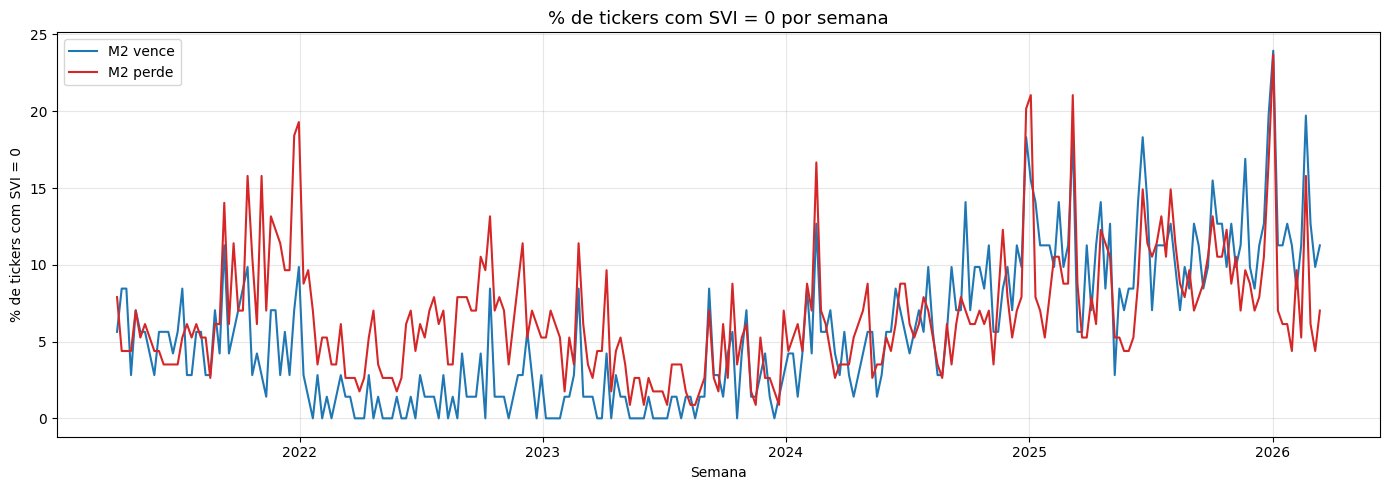

In [ ]:
import matplotlib.pyplot as plt

# % de tickers com svi=0 por semana, separado por grupo
df_final["grupo"] = np.where(
    df_final["ticker_b3"].isin(tickers_m2_vence), "M2 vence", "M2 perde"
)

zeros_semana = (
    df_final.groupby(["semana", "grupo"])
    .apply(lambda x: (x["svi"] == 0).mean() * 100)
    .reset_index(name="pct_zeros")
)

fig, ax = plt.subplots(figsize=(14, 5))

for grupo, cor in [("M2 vence", "#1f77b4"), ("M2 perde", "#d62728")]:
    d = zeros_semana[zeros_semana["grupo"] == grupo]
    ax.plot(d["semana"], d["pct_zeros"], label=grupo, color=cor, linewidth=1.5)

ax.set_title("% de tickers com SVI = 0 por semana", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("% de tickers com SVI = 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()